In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# ---------------------------------------------------------
# Performance variation = highest score - lowest score
# Lower variation is better.
# ---------------------------------------------------------

metrics = ["OA", "AA", "Kappa"]

Block split average variation: [17.81666667 17.77       22.88666667]
PCA + Block split average variation: [15.56666667 16.6        20.18333333]
Reduction: [2.25       1.17       2.70333333]


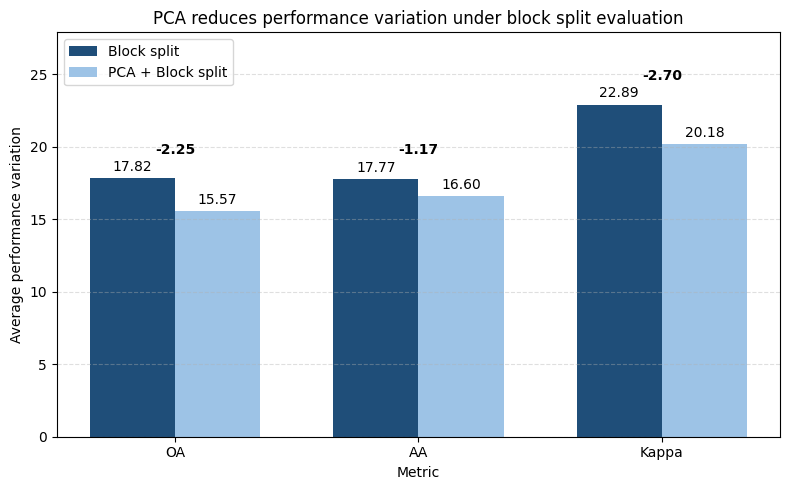

In [10]:
# Block split only
block_ip = np.array([99.60 - 82.30, 99.12 - 79.12, 99.54 - 79.74])
block_up = np.array([99.96 - 85.24, 99.90 - 85.71, 99.94 - 80.33])
block_sa = np.array([99.99 - 78.56, 99.98 - 80.86, 99.99 - 70.74])

# PCA + Block split
pca_ip = np.array([99.63 - 84.44, 98.72 - 80.07, 99.57 - 82.17])
pca_up = np.array([99.95 - 88.76, 99.90 - 87.24, 99.94 - 84.59])
pca_sa = np.array([99.99 - 79.67, 99.98 - 81.49, 99.99 - 72.19])

# Average variation across the three datasets
block_avg = np.mean([block_ip, block_up, block_sa], axis=0)
pca_avg = np.mean([pca_ip, pca_up, pca_sa], axis=0)

# Reduction in variation
reduction = block_avg - pca_avg

print("Block split average variation:", block_avg)
print("PCA + Block split average variation:", pca_avg)
print("Reduction:", reduction)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

x = np.arange(len(metrics))
width = 0.35

dark_color = "#1f4e79"    # darker: Block split
light_color = "#9dc3e6"   # lighter: PCA + Block split

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    block_avg,
    width,
    label="Block split",
    color=dark_color
)

bars2 = plt.bar(
    x + width / 2,
    pca_avg,
    width,
    label="PCA + Block split",
    color=light_color
)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

# Reduction labels
for i, diff in enumerate(reduction):
    higher_value = max(block_avg[i], pca_avg[i])

    plt.text(
        x[i],
        higher_value + 1.5,
        f"-{diff:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.xlabel("Metric")
plt.ylabel("Average performance variation")
plt.title("PCA reduces performance variation under block split evaluation")

plt.xticks(x, metrics)
plt.ylim(0, max(block_avg) + 5)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("average_performance_variation.png", dpi=300)
plt.show()